# Linear Regression

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset  = pd.read_csv('Algerian_forest_fires_2.csv')

In [4]:
dataset

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,Bejaia,04/06/2012,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,Bejaia,29/06/2012,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,Sidi-Bel Abbes,18/06/2012,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,Sidi-Bel Abbes,21/09/2012,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,Sidi-Bel Abbes,08/08/2012,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,Bejaia,10/06/2012,10,June,2012,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,Not Fire
240,Bejaia,12/06/2012,12,June,2012,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,Not Fire
241,Bejaia,29/07/2012,29,July,2012,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,Not Fire
242,Sidi-Bel Abbes,27/08/2012,27,August,2012,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,Not Fire


In [5]:
dataset.head()

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,Bejaia,04/06/2012,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,Bejaia,29/06/2012,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,Sidi-Bel Abbes,18/06/2012,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,Sidi-Bel Abbes,21/09/2012,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,Sidi-Bel Abbes,08/08/2012,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire


In [6]:
dataset.shape

(244, 16)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    object 
 1   Date     244 non-null    object 
 2   Day      244 non-null    int64  
 3   Month    244 non-null    object 
 4   Year     244 non-null    int64  
 5   Temp     244 non-null    int64  
 6   RH       244 non-null    int64  
 7   Ws       244 non-null    int64  
 8   Rain     244 non-null    float64
 9   FFMC     244 non-null    float64
 10  DMC      244 non-null    float64
 11  DC       244 non-null    float64
 12  ISI      244 non-null    float64
 13  BUI      244 non-null    float64
 14  FWI      244 non-null    float64
 15  Classes  244 non-null    object 
dtypes: float64(7), int64(5), object(4)
memory usage: 30.6+ KB


## Data Cleaning

In [8]:
dataset.isnull().sum()

Region     0
Date       0
Day        0
Month      0
Year       0
Temp       0
RH         0
Ws         0
Rain       0
FFMC       0
DMC        0
DC         0
ISI        0
BUI        0
FWI        0
Classes    0
dtype: int64

In [9]:
dataset[dataset.isnull().any(axis=1)]   # Data missing check

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [10]:
dataset['Region'] = dataset['Region'].replace({
    'Bejaia': 0,
    'Sidi-Bel Abbes': 1
})

print(dataset.head())

   Region        Date  Day      Month  Year  Temp  RH  Ws  Rain  FFMC   DMC  \
0       0  04/06/2012    4       June  2012    31  37  13   0.7  41.7  51.6   
1       0  29/06/2012   29       June  2012    28  58  12   3.1  87.1  52.1   
2       1  18/06/2012   18       June  2012    41  36  21   6.3  33.4  18.9   
3       1  21/09/2012   21  September  2012    40  56   7   9.5  79.1  34.6   
4       1  08/08/2012    8     August  2012    27  32  28   3.1  49.0  51.6   

      DC   ISI   BUI   FWI   Classes  
0  192.3  12.9  66.7  27.4      Fire  
1  215.2  11.5  18.8  14.4      Fire  
2  164.6  18.4  53.7   1.3      Fire  
3  122.1  17.7  61.3  18.7  Not Fire  
4  145.2   8.4  19.3  18.6      Fire  


C:\Users\abhay\AppData\Local\Temp\ipykernel_16920\2700355250.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['Region'] = dataset['Region'].replace({


In [11]:
dataset.head()

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,04/06/2012,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29/06/2012,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18/06/2012,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21/09/2012,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,08/08/2012,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire


In [12]:
dataset

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,04/06/2012,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29/06/2012,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18/06/2012,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21/09/2012,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,08/08/2012,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,10/06/2012,10,June,2012,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,Not Fire
240,0,12/06/2012,12,June,2012,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,Not Fire
241,0,29/07/2012,29,July,2012,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,Not Fire
242,1,27/08/2012,27,August,2012,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,Not Fire


In [13]:
df = dataset

In [14]:
df

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,04/06/2012,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29/06/2012,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18/06/2012,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21/09/2012,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,08/08/2012,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,10/06/2012,10,June,2012,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,Not Fire
240,0,12/06/2012,12,June,2012,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,Not Fire
241,0,29/07/2012,29,July,2012,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,Not Fire
242,1,27/08/2012,27,August,2012,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,Not Fire


In [15]:
df.head()

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,04/06/2012,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29/06/2012,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18/06/2012,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21/09/2012,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,08/08/2012,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire


In [16]:
df.tail()

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
239,0,10/06/2012,10,June,2012,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,Not Fire
240,0,12/06/2012,12,June,2012,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,Not Fire
241,0,29/07/2012,29,July,2012,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,Not Fire
242,1,27/08/2012,27,August,2012,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,Not Fire
243,0,29/08/2012,29,August,2012,29,45,17,12.9,91.5,51.6,74.5,18.4,23.0,22.1,Fire


In [17]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Date     244 non-null    object 
 2   Day      244 non-null    int64  
 3   Month    244 non-null    object 
 4   Year     244 non-null    int64  
 5   Temp     244 non-null    int64  
 6   RH       244 non-null    int64  
 7   Ws       244 non-null    int64  
 8   Rain     244 non-null    float64
 9   FFMC     244 non-null    float64
 10  DMC      244 non-null    float64
 11  DC       244 non-null    float64
 12  ISI      244 non-null    float64
 13  BUI      244 non-null    float64
 14  FWI      244 non-null    float64
 15  Classes  244 non-null    object 
dtypes: float64(7), int64(6), object(3)
memory usage: 30.6+ KB


In [18]:
df.isnull().sum()

Region     0
Date       0
Day        0
Month      0
Year       0
Temp       0
RH         0
Ws         0
Rain       0
FFMC       0
DMC        0
DC         0
ISI        0
BUI        0
FWI        0
Classes    0
dtype: int64

In [19]:
#  removing the null values
df =df.dropna().reset_index(drop=True)

In [20]:
df

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,04/06/2012,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29/06/2012,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18/06/2012,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21/09/2012,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,08/08/2012,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,10/06/2012,10,June,2012,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,Not Fire
240,0,12/06/2012,12,June,2012,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,Not Fire
241,0,29/07/2012,29,July,2012,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,Not Fire
242,1,27/08/2012,27,August,2012,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,Not Fire


In [21]:
df.isnull().sum()

Region     0
Date       0
Day        0
Month      0
Year       0
Temp       0
RH         0
Ws         0
Rain       0
FFMC       0
DMC        0
DC         0
ISI        0
BUI        0
FWI        0
Classes    0
dtype: int64

In [22]:
df.iloc()

In [23]:
df.shape

(244, 16)

In [24]:
df.columns

Index(['Region', 'Date', 'Day', 'Month', 'Year', 'Temp', 'RH', 'Ws', 'Rain',
       'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [25]:
df.columns = df.columns.str.strip()

In [26]:
df.columns

Index(['Region', 'Date', 'Day', 'Month', 'Year', 'Temp', 'RH', 'Ws', 'Rain',
       'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Date     244 non-null    object 
 2   Day      244 non-null    int64  
 3   Month    244 non-null    object 
 4   Year     244 non-null    int64  
 5   Temp     244 non-null    int64  
 6   RH       244 non-null    int64  
 7   Ws       244 non-null    int64  
 8   Rain     244 non-null    float64
 9   FFMC     244 non-null    float64
 10  DMC      244 non-null    float64
 11  DC       244 non-null    float64
 12  ISI      244 non-null    float64
 13  BUI      244 non-null    float64
 14  FWI      244 non-null    float64
 15  Classes  244 non-null    object 
dtypes: float64(7), int64(6), object(3)
memory usage: 30.6+ KB


In [28]:
df.head()

,Region,Date,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,04/06/2012,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29/06/2012,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18/06/2012,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21/09/2012,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,08/08/2012,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire


In [29]:
df = df.drop('Date',axis=1)

In [30]:
df['Month'].unique()

array(['June', 'September', 'August', 'July'], dtype=object)

In [31]:
df.head()

,Region,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,4,June,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29,June,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18,June,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21,September,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,8,August,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire


In [32]:
df['Month'] = df['Month'].replace({
    'June':6,
      'September':9, 'August':8, 'July':7
    
})

print(df.head())

   Region  Day  Month  Year  Temp  RH  Ws  Rain  FFMC   DMC     DC   ISI  \
0       0    4      6  2012    31  37  13   0.7  41.7  51.6  192.3  12.9   
1       0   29      6  2012    28  58  12   3.1  87.1  52.1  215.2  11.5   
2       1   18      6  2012    41  36  21   6.3  33.4  18.9  164.6  18.4   
3       1   21      9  2012    40  56   7   9.5  79.1  34.6  122.1  17.7   
4       1    8      8  2012    27  32  28   3.1  49.0  51.6  145.2   8.4   

    BUI   FWI   Classes  
0  66.7  27.4      Fire  
1  18.8  14.4      Fire  
2  53.7   1.3      Fire  
3  61.3  18.7  Not Fire  
4  19.3  18.6      Fire  


C:\Users\abhay\AppData\Local\Temp\ipykernel_16920\640029291.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Month'] = df['Month'].replace({


In [33]:
df

,Region,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,4,6,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29,6,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18,6,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21,9,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,8,8,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,10,6,2012,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,Not Fire
240,0,12,6,2012,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,Not Fire
241,0,29,7,2012,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,Not Fire
242,1,27,8,2012,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,Not Fire


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Day      244 non-null    int64  
 2   Month    244 non-null    int64  
 3   Year     244 non-null    int64  
 4   Temp     244 non-null    int64  
 5   RH       244 non-null    int64  
 6   Ws       244 non-null    int64  
 7   Rain     244 non-null    float64
 8   FFMC     244 non-null    float64
 9   DMC      244 non-null    float64
 10  DC       244 non-null    float64
 11  ISI      244 non-null    float64
 12  BUI      244 non-null    float64
 13  FWI      244 non-null    float64
 14  Classes  244 non-null    object 
dtypes: float64(7), int64(7), object(1)
memory usage: 28.7+ KB


In [35]:
df[['Month','Day','Year','Temp','RH','Ws']]= df[['Month','Day','Year','Temp','RH','Ws']].astype(int)

In [36]:
df

,Region,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,4,6,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29,6,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18,6,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21,9,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,8,8,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,10,6,2012,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,Not Fire
240,0,12,6,2012,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,Not Fire
241,0,29,7,2012,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,Not Fire
242,1,27,8,2012,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,Not Fire


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Day      244 non-null    int64  
 2   Month    244 non-null    int64  
 3   Year     244 non-null    int64  
 4   Temp     244 non-null    int64  
 5   RH       244 non-null    int64  
 6   Ws       244 non-null    int64  
 7   Rain     244 non-null    float64
 8   FFMC     244 non-null    float64
 9   DMC      244 non-null    float64
 10  DC       244 non-null    float64
 11  ISI      244 non-null    float64
 12  BUI      244 non-null    float64
 13  FWI      244 non-null    float64
 14  Classes  244 non-null    object 
dtypes: float64(7), int64(7), object(1)
memory usage: 28.7+ KB


In [38]:
df[['Rain','FFMC','DMC','DC','ISI','BUI','FWI']]= df[['Rain','FFMC','DMC','DC','ISI','BUI','FWI']].astype(float)


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Day      244 non-null    int64  
 2   Month    244 non-null    int64  
 3   Year     244 non-null    int64  
 4   Temp     244 non-null    int64  
 5   RH       244 non-null    int64  
 6   Ws       244 non-null    int64  
 7   Rain     244 non-null    float64
 8   FFMC     244 non-null    float64
 9   DMC      244 non-null    float64
 10  DC       244 non-null    float64
 11  ISI      244 non-null    float64
 12  BUI      244 non-null    float64
 13  FWI      244 non-null    float64
 14  Classes  244 non-null    object 
dtypes: float64(7), int64(7), object(1)
memory usage: 28.7+ KB


In [40]:
df.head()


,Region,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,4,6,2012,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,29,6,2012,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,18,6,2012,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,21,9,2012,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,8,8,2012,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire


In [41]:
df.describe()

,Region,Day,Month,Year,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
count,244.000000,244.000000,244.000000,244.0,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,0.500000,15.713115,7.459016,2012.0,31.397541,56.426230,17.217213,7.996721,58.978689,34.569672,115.168033,9.071311,34.407377,16.153279
std,0.501028,8.770020,1.123249,0.0,6.193199,19.943095,6.917351,4.740308,18.812828,19.266937,61.685538,5.398567,19.236042,8.806551
min,0.000000,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.100000,29.300000,1.500000,8.100000,0.200000,1.300000,0.400000
25%,0.000000,8.000000,6.000000,2012.0,26.000000,39.000000,11.000000,3.575000,42.775000,16.075000,59.775000,4.275000,17.750000,8.700000
50%,0.500000,16.000000,7.000000,2012.0,31.000000,54.000000,18.000000,7.800000,58.200000,36.400000,116.050000,9.100000,35.950000,16.250000
75%,1.000000,22.000000,8.000000,2012.0,37.000000,74.000000,23.000000,12.150000,74.950000,51.450000,163.575000,13.600000,51.025000,24.100000
max,1.000000,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.600000,92.400000,65.700000,220.300000,18.400000,67.900000,31.000000


# EDA and FE

In [42]:
df_copy =df.drop(['Day','Month','Year'],axis=1)

In [43]:
df_copy

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,Fire
1,0,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,Fire
2,1,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,Fire
3,1,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,Not Fire
4,1,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,Fire
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,Not Fire
240,0,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,Not Fire
241,0,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,Not Fire
242,1,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,Not Fire


In [44]:
df_copy['Classes'].value_counts()

Classes
Fire        138
Not Fire    106
Name: count, dtype: int64

In [45]:
df_copy['Classes'] =np.where(df_copy['Classes'].str.contains('Not Fire'),0,1)

In [46]:
df_copy

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,31,37,13,0.7,41.7,51.6,192.3,12.9,66.7,27.4,1
1,0,28,58,12,3.1,87.1,52.1,215.2,11.5,18.8,14.4,1
2,1,41,36,21,6.3,33.4,18.9,164.6,18.4,53.7,1.3,1
3,1,40,56,7,9.5,79.1,34.6,122.1,17.7,61.3,18.7,0
4,1,27,32,28,3.1,49.0,51.6,145.2,8.4,19.3,18.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,37,42,9,8.5,29.8,63.5,217.5,2.2,67.8,4.4,0
240,0,42,53,20,2.8,38.1,65.3,55.8,0.4,14.9,1.6,0
241,0,29,40,27,16.3,85.8,55.0,50.9,1.6,24.9,22.1,0
242,1,38,52,6,9.6,59.9,9.2,105.9,13.6,6.5,9.3,0


In [47]:
df_copy.to_csv('copy_Algerian_forest.csv', index=False)

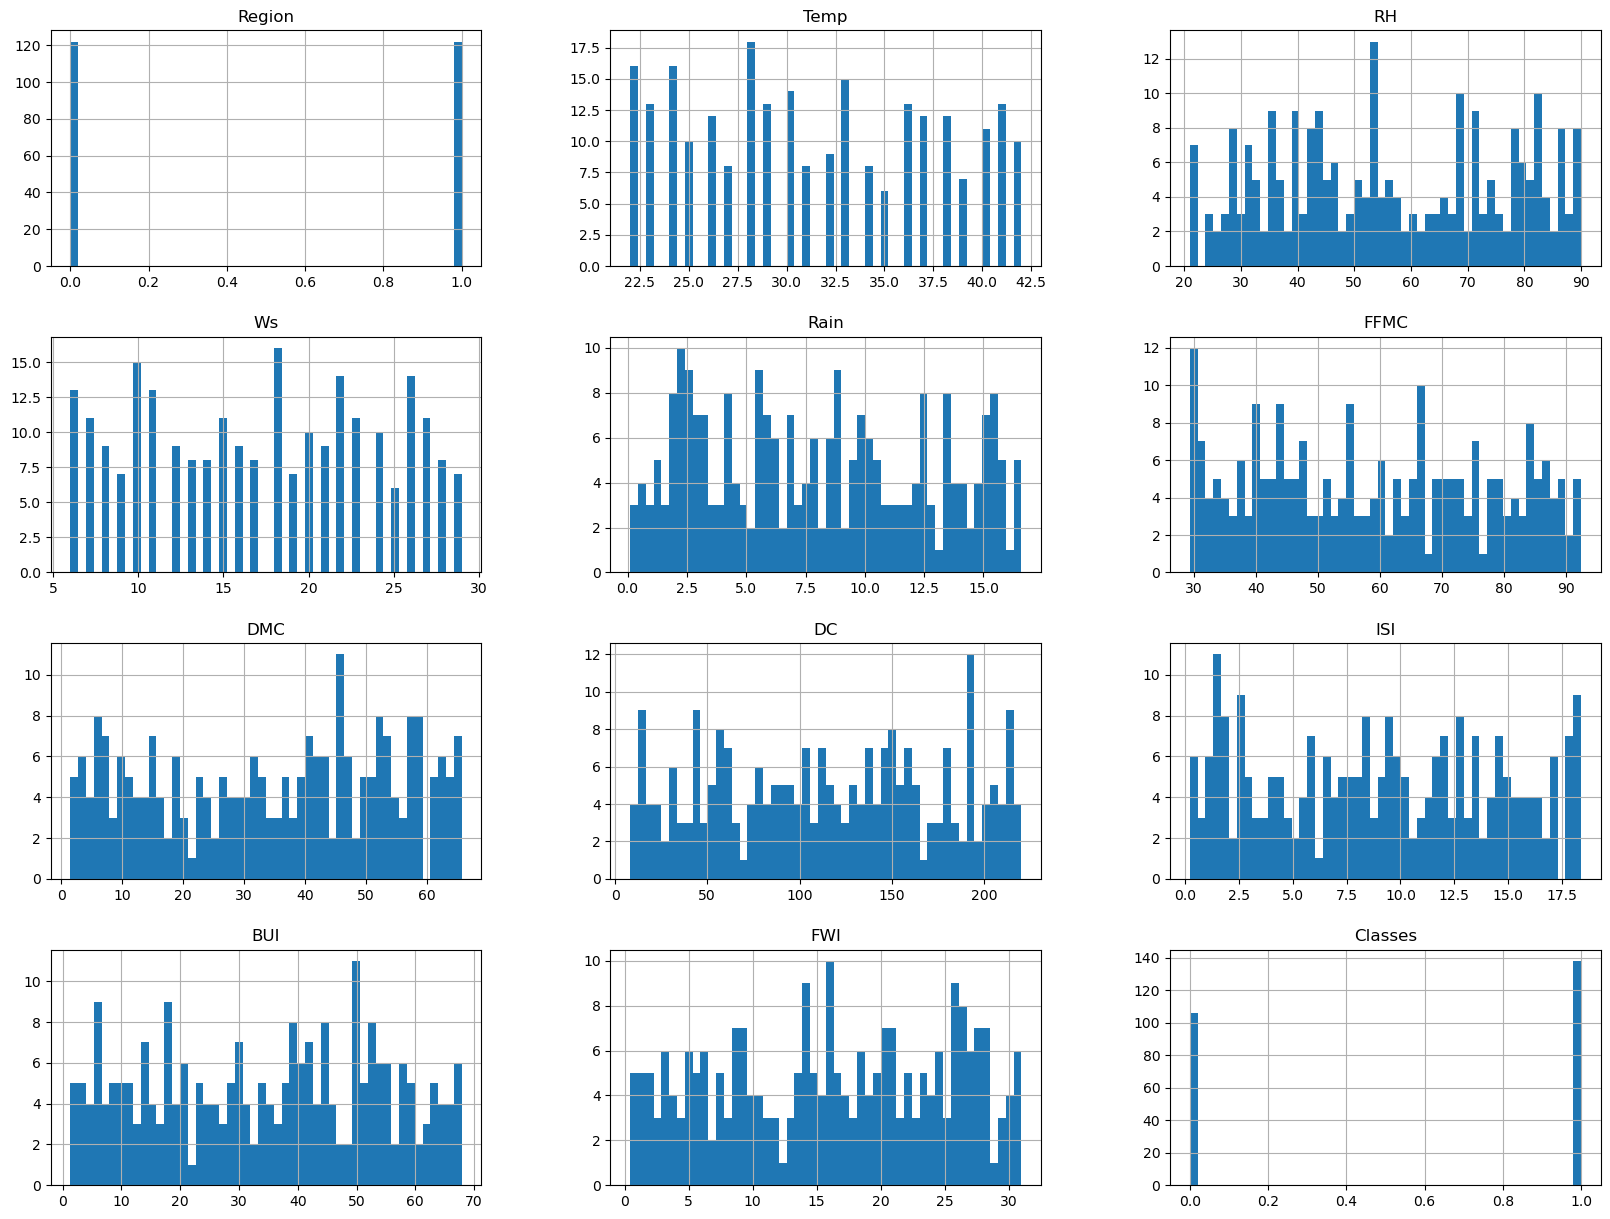

In [48]:
df_copy.hist(bins = 50, figsize=(20,15))
plt.show()

In [49]:
# Coorelation
df_copy.corr()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
Region,1.000000,0.007294,-0.069603,-0.013655,0.216069,0.093999,-0.095449,0.044420,-0.073485,-0.075492,-0.031617,-0.049609
Temp,0.007294,1.000000,-0.080209,0.063200,0.043177,-0.085367,0.057810,0.004126,0.051471,-0.015998,0.036008,-0.112187
RH,-0.069603,-0.080209,1.000000,-0.103559,-0.017132,0.055408,0.066760,0.037361,-0.034715,0.008105,-0.017741,0.027494
Ws,-0.013655,0.063200,-0.103559,1.000000,-0.001560,0.018250,0.054817,-0.059206,-0.029939,-0.052913,0.060472,-0.041891
Rain,0.216069,0.043177,-0.017132,-0.001560,1.000000,0.105414,-0.016996,0.073075,0.116684,0.069916,0.026661,-0.023154
FFMC,0.093999,-0.085367,0.055408,0.018250,0.105414,1.000000,-0.021414,0.046188,-0.043657,-0.040619,0.031376,-0.050936
DMC,-0.095449,0.057810,0.066760,0.054817,-0.016996,-0.021414,1.000000,0.005414,-0.002910,-0.068000,-0.171713,-0.050361
DC,0.044420,0.004126,0.037361,-0.059206,0.073075,0.046188,0.005414,1.000000,-0.013570,0.111493,-0.057008,0.028368
ISI,-0.073485,0.051471,-0.034715,-0.029939,0.116684,-0.043657,-0.002910,-0.013570,1.000000,0.072869,0.065291,-0.049787
BUI,-0.075492,-0.015998,0.008105,-0.052913,0.069916,-0.040619,-0.068000,0.111493,0.072869,1.000000,-0.050153,-0.044026


<Axes: >

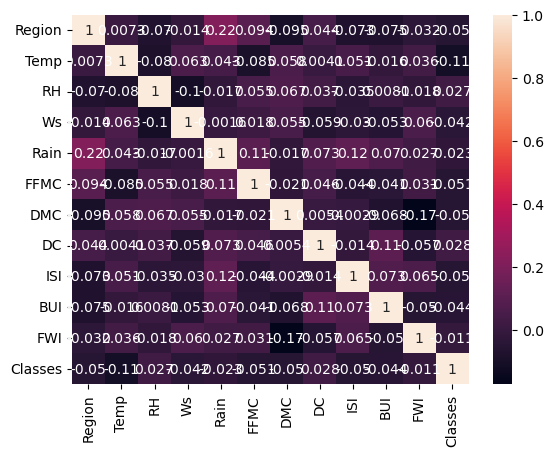

In [50]:
sns.heatmap(df_copy.corr(), annot=True)